$$
\newcommand{\bfbeta}{\boldsymbol{\beta}}
\newcommand{\bflambda}{\boldsymbol{\lambda}}
$$

***

*Course:* [Math 535](https://people.math.wisc.edu/~roch/mmids/) - Mathematical Methods in Data Science (MMiDS)  
*Chapter:* 2-Least squares   
*Author:* [Sebastien Roch](https://people.math.wisc.edu/~roch/), Department of Mathematics, University of Wisconsin-Madison  
*Updated:* Jan 4, 2024   
*Copyright:* &copy; 2024 Sebastien Roch

***

In [1]:
# FOR BOOK ONLY
import warnings
warnings.filterwarnings('ignore')
import os, sys
sys.path.insert(0, os.path.abspath('../../utils')) # use directory to mmids.py
#plt.rcParams['figure.figsize'] = [4.00, 2.25] # for high-def figs
#plt.rcParams['figure.dpi'] = 200 # for high-def figs

In [2]:
# PYTHON 3
import numpy as np
from numpy import linalg as LA
from numpy.random import default_rng
rng = default_rng(535)
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import mmids

## Overdetermined linear systems and regression analysis

We return to one of our motivating examples, linear regression. At a high level, we are given $A \in \mathbb{R}^{n\times m}$ an $n\times m$ matrix and $\mathbf{b} \in \mathbb{R}^n$ a vector. We are looking to solve the system

$$
A \mathbf{x} \approx \mathbf{b}.
$$ 

We begin with the important special case where $A$ is invertible.

### Linear systems and inverses

**DEFINITION** **(Nonsingular Matrix)** A square matrix $A \in \mathbb{R}^{n \times n}$ is nonsingular if it has rank $n$. In that case, we also say that $A$ is of full rank. $\natural$

An implication of this is that $A$ is nonsingular if and only if its columns form a basis of $\mathbb{R}^n$. Indeed, suppose the columns of $A$ form a basis of $\mathbb{R}^n$. Then the dimension of $\mathrm{col}(A)$ is $n$, which means the rank is $n$. In the other direction, suppose $A$ has rank $n$. 

1. We first prove a general statement: the columns of $Z \in \mathbb{R}^{k \times m}$ form a basis of $\mathrm{col}(Z)$ whenever $Z$ is of full column rank. Indeed, the columns of $Z$ by definition span $\mathrm{col}(Z)$. By the *Reducing a Spanning List Lemma*, they can be reduced into a basis of $\mathrm{col}(Z)$. If $Z$ has full column rank, then the length of any basis of $\mathrm{col}(Z)$ is equal to the number of columns of $Z$. So the columns of $Z$ must already form a basis.

2. Apply the previous claim to $Z = A$. Then, since the columns of $A$ form an independent list in $\mathbb{R}^n$, by the *Completing an Independent List Lemma* they can be completed into a basis of $\mathbb{R}^n$. But there are already $n$ of them, the dimension of $\mathbb{R}^n$, so they must already form a basis of $\mathbb{R}^n$. In other words, we have proved another general fact: an independent list of length $n$ in $\mathbb{R}^n$ is a basis of $\mathbb{R}^n$.

Equivalently:

**LEMMA** **(Invertibility)** A square matrix $A \in \mathbb{R}^{n \times n}$ is nonsingular if and only if there exists a unique $A^{-1}$ such that

$$
A A^{-1} = A^{-1} A = I_{n \times n}.
$$

The matrix $A^{-1}$ is referred to as the inverse of $A$. We also say that $A$ is invertible. $\flat$

*Proof idea:* We use the nonsingularity of $A$ to write the columns of the identity matrix as unique linear combinations of the columns of $A$.

*Proof:* Suppose first that $A$ has rank $n$. Then its columns are linearly independent and form a basis of $\mathbb{R}^n$. In particular, for any $i$ the standard basis vector $\mathbf{e}_i$ can be written as a unique linear combination of the columns of $A$, i.e., there is $\mathbf{b}_i$ such that $A \mathbf{b}_i =\mathbf{e}_i$. Let $B$ be the matrix with columns $\mathbf{b}_i$, $i=1,\ldots,n$. By construction, $A B = I_{n\times n}$. Applying the same idea to the rows of $A$ (which by the *Row Rank Equals Column Rank Lemma* also form a basis of $\mathbb{R}^n$), there is a unique $C$ such that $C A = I_{n\times n}$. Multiplying both sides by $B$, we get

$$
C = C A B = I_{n \times n} B = B.
$$

So we take $A^{-1} = B = C$.

In the other direction, following the same argument, the equation $A A^{-1} = I_{n \times n}$ implies that the standard basis of $\mathbb{R}^n$ is in the column space of $A$. So the columns of $A$ are a spanning list of all of $\mathbb{R}^n$ and $\mathrm{rk}(A) = n$. That proves the claim. $\square$

 **THEOREM** **(Inverting a Nonsingular System)** Let $A \in \mathbb{R}^{n \times n}$ be a nonsingular square matrix. Then for any $\mathbf{b} \in \mathbb{R}^n$, there exists a unique $\mathbf{x} \in \mathbb{R}^n$ such that $A \mathbf{x} = \mathbf{b}$. Moreover $\mathbf{x} = A^{-1} \mathbf{b}$. $\sharp$

*Proof:* The first claim follows immediately from the fact that the columns of $A$ form a basis of $\mathbb{R}^n$. For the second claim, note that 

$$
\mathbf{x} = A^{-1} A \mathbf{x} = A^{-1} \mathbf{b}.
$$ 

$\square$

**EXAMPLE:** Let $A \in \mathbb{R}^{n \times m}$ with $n \geq m$ have full column rank, i.e. rank $m$. We will show that the square matrix $B = A^T A$ is then invertible.

By a claim above, the columns of $A$ form a basis of its column space. In particular they are linearly independent. We will use this below. 

Observe that $B$ is an $m \times m$ matrix. By definition, to show that it is nonsingular, we need to establish that it has rank $m$, or put differently that its columns are also linearly independent. By the matrix version of the *Equivalent Definition of Linear Independence*, it suffices to show that 

$$
B \mathbf{x} = \mathbf{0} \implies \mathbf{x} = \mathbf{0}.
$$

We establish this next.

Since $B = A^T A$, the equation $B \mathbf{x} = \mathbf{0}$ implies

$$
A^T A \mathbf{x} = \mathbf{0}.
$$

Now comes the key idea: we multiply both sides by $\mathbf{x}^T$. The left-hand side becomes 

$$
\mathbf{x}^T (A^T A \mathbf{x}) 
= (A \mathbf{x})^T (A \mathbf{x}) 
= \|A \mathbf{x}\|^2,
$$

where we used that, for matrices $C, D$, we have $(CD)^T = D^T C^T$. The right-hand side becomes $\mathbf{x}^T \mathbf{0} = 0$. Hence we have shown that $A^T A \mathbf{x} = \mathbf{0}$ in fact implies $\|A \mathbf{x}\|^2 = 0$.

By the point-separating property of the Euclidean norm, the condition $\|A \mathbf{x}\|^2 = 0$ implies $A \mathbf{x} = \mathbf{0}$. Because $A$ has linearly independent columns, the *Equivalent Definition of Linear Independence* in its matrix form again implies that $\mathbf{x} = \mathbf{0}$, which is what we needed to prove. $\lhd$

**EXAMPLE:** Let $\mathbf{q}_1,\ldots,\mathbf{q}_n$ be an orthonormal basis of $\mathbb{R}^n$ and form the matrix 

$$
Q =
\begin{pmatrix}
| &  & | \\
\mathbf{q}_1 & \ldots & \mathbf{q}_n \\
| &  & | 
\end{pmatrix}.
$$

We show that $Q^{-1} = Q^T$. 

By the definition of matrix multiplication 

$$
Q^T Q
=
\begin{pmatrix}
\langle \mathbf{q}_1, \mathbf{q}_1 \rangle & \cdots & \langle \mathbf{q}_1, \mathbf{q}_n \rangle \\
\langle \mathbf{q}_2, \mathbf{q}_1 \rangle & \cdots & \langle \mathbf{q}_2, \mathbf{q}_n \rangle \\
\vdots & \ddots & \vdots \\
\langle \mathbf{q}_n, \mathbf{q}_1 \rangle & \cdots & \langle \mathbf{q}_n, \mathbf{q}_n \rangle
\end{pmatrix}
= I_{n \times n}
$$

where $I_{n \times n}$ denotes the $n \times n$ identity matrix. This of course follows from the fact that the $\mathbf{q}_i$'s are orthonormal. 

In the other direction, we claim that $Q Q^T = I_{n \times n}$ as well. Indeed the matrix $Q Q^T$ is the orthogonal projection on the span of the $\mathbf{q}_i$'s, that is, $\mathbb{R}^n$. By the *Orthogonal Projection Theorem*, the orthogonal projection $Q Q^T \mathbf{v}$ finds the closest vector to $\mathbf{v}$ in the span of the $\mathbf{q}_i$'s. But that span contains all vectors, including $\mathbf{v}$, so we must have $Q Q^T \mathbf{v} = \mathbf{v}$. Since this holds for all $\mathbf{v} \in \mathbb{R}^n$, the matrix $Q Q^T$ is the identity map and we have proved the claim. $\lhd$

Matrices that satisfy 

$$
Q^T Q = Q Q^T = I_{n \times n}
$$ 

are called orthogonal matrices.

**DEFINITION** **(Orthogonal Matrix)** A square matrix $Q \in \mathbb{R}^{m\times m}$ is orthogonal if $Q^T Q = Q Q^T = I_{m \times m}$. $\lhd$

### Overdetermined case

In this section, we discuss the least-squares problem. Let again $A \in \mathbb{R}^{n\times m}$ be an $n\times m$ matrix with linearly independent columns and let $\mathbf{b} \in \mathbb{R}^n$ be a vector. We are looking to solve the system

$$
A \mathbf{x} \approx \mathbf{b}.
$$

If $n=m$, we can use the [matrix inverse](https://en.wikipedia.org/wiki/Invertible_matrix) to solve the system, as discussed in the previous subsection. But we are particularly interested in the overdetermined case, i.e. when $n > m$: there are more equations than variables. We cannot use the matrix inverse then. Indeed, because the columns do not span all of $\mathbb{R}^n$, there is a vector $\mathbf{b} \in \mathbb{R}^n$ that is not in the column space of $A$.

A natural way to make sense of the overdetermined problem is to cast it as the [linear least squares problem](https://en.wikipedia.org/wiki/Least_squares)

$$
\min_{\mathbf{x} \in \mathbb{R}^m} \|A \mathbf{x} - \mathbf{b}\|.
$$

In words, we look for the best-fitting solution under the Euclidean norm. Equivalently, writing

$$
A =
\begin{pmatrix}
| &  & | \\
\mathbf{a}_1 & \ldots & \mathbf{a}_m \\
| &  & | 
\end{pmatrix}
=
\begin{pmatrix}
a_{11} & \cdots & a_{1m} \\
a_{21} & \cdots & a_{2m} \\
\vdots & \ddots & \vdots \\
a_{n1} & \cdots & a_{nm}
\end{pmatrix}
\quad
\text{and}
\quad
\mathbf{b}
=
\begin{pmatrix}
b_1 \\
\vdots \\
b_n
\end{pmatrix}
$$

we seek a linear combination of the columns of $A$ that minimizes the objective

$$
\left\|\,\sum_{j=1}^m x_j \mathbf{a}_j - \mathbf{b}\,\right\|^2
= \sum_{i=1}^n \left(
\sum_{j=1}^m  a_{ij} x_j - b_i
\right)^2.
$$

We have already solved a closely related problem when we introduced the orthogonal projection. We make the connection explicit next. 

**THEOREM** **(Normal Equations)** Let $A \in \mathbb{R}^{n\times m}$ be an $n\times m$ matrix with $n \geq m$ and let $\mathbf{b} \in \mathbb{R}^n$ be a vector. A solution $\mathbf{x}^*$ to the linear least squares problem

$$
\min_{\mathbf{x} \in \mathbb{R}^m} \|A \mathbf{x} - \mathbf{b}\|
$$

satisfies the normal equations

$$
A^T A \mathbf{x}^* = A^T \mathbf{b}.
$$

If further the columns of $A$ are linearly independent, then there exists a unique solution $\mathbf{x}^*$. $\sharp$

*Proof idea:* Apply our characterization of the orthogonal projection onto the column space of $A$. 

*Proof:* Let $U = \mathrm{col}(A) = \mathrm{span}(\mathbf{a}_1,\ldots,\mathbf{a}_m)$. By the *Orthogonal Projection Theorem*, the orthogonal projection $\mathbf{p}^* = \mathrm{proj}_{U} \mathbf{b}$ of $\mathbf{b}$ onto $U$ is the unique, closest vector to $\mathbf{b}$ in $U$, that is,

$$
\mathbf{p}^* = \arg\min_{\mathbf{p} \in U} \|\mathbf{p} - \mathbf{b}\|. 
$$

Because $\mathbf{p}^*$ is in $U = \mathrm{col}(A)$, it must be of the form $\mathbf{p}^* = A \mathbf{x}^*$. This establishes that $\mathbf{x}^*$ is a solution to the linear least squares problem in the statement. 

*Important observation:* while we have shown that $\mathbf{p}^*$ is unique (by the *Orthogonal Projection Theorem*), it is not clear at all that $\mathbf{x}^*$ (i.e., the linear combination of columns of $A$ corresponding to $\mathbf{p}^*$) is unique. By the *Orthogonal Projection Theorem*, it must satisfy $\langle \mathbf{b} - A \mathbf{x}^*, \mathbf{u}\rangle = 0$ for all $\mathbf{u} \in U$. Because the columns $\mathbf{a}_i$ are in $U$, that implies that 

$$
0 = \langle \mathbf{b} - A \mathbf{x}^*, \mathbf{a}_i\rangle 
= \mathbf{a}_i^T (\mathbf{b} - A \mathbf{x}^*) ,\qquad \forall i\in [m].
$$ 

Stacking up these equations gives in matrix form

$$
A^T (\mathbf{b} - A\mathbf{x}^*) = \mathbf{0},
$$

as claimed. 

We have seen in a previous example that, when $A$ has full column rank, the matrix $A^T A$ is invertible. That proves the uniqueness claim. $\square$

**NUMERICAL CORNER:** To solve a linear system in Numpy, use [`numpy.linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html). As an example, we consider the overdetermined system with

$$
A = \begin{pmatrix}
1 & 0\\
0 & 1\\
1 & 1
\end{pmatrix}
\quad
\text{and}
\quad
\mathbf{b} = \begin{pmatrix}
0\\
0\\
2
\end{pmatrix}.
$$

We use [`numpy.ndarray.T`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.T.html) for the transpose.

In [3]:
w1 = np.array([1., 0., 1.])
w2 = np.array([0., 1., 1.])
A = np.stack((w1, w2),axis=-1)
b = np.array([0., 0., 2.])
x = LA.solve(A.T @ A, A.T @ b)
print(x)

[0.66666667 0.66666667]


We can also use [`numpy.linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) directly on the overdetermined system to compute the least-square solution.

In [4]:
x = LA.lstsq(A, b, rcond=None)[0]
print(x)

[0.66666667 0.66666667]


$\unlhd$

### Least squares via Cholesky

In a first linear algebra course, one learns how to solve a square linear system such as the normal equations. For this task a common approach is Gaussian elimination, or row reduction. Quoting [Wikipedia](https://en.wikipedia.org/wiki/Gaussian_elimination): 

> To perform row reduction on a matrix, one uses a sequence of elementary row operations to modify the matrix until the lower left-hand corner of the matrix is filled with zeros, as much as possible. [...] Once all of the leading coefficients (the leftmost nonzero entry in each row) are 1, and every column containing a leading coefficient has zeros elsewhere, the matrix is said to be in reduced row echelon form. [...] The process of row reduction [...] can be divided into two parts. The first part (sometimes called forward elimination) reduces a given system to row echelon form, from which one can tell whether there are no solutions, a unique solution, or infinitely many solutions. The second part (sometimes called back substitution) continues to use row operations until the solution is found; in other words, it puts the matrix into reduced row echelon form.

Here is an example.

![Gaussian elimination](https://wikimedia.org/api/rest_v1/media/math/render/svg/65d92f997de9f7ad787b95d08fcd25dca828dd93)

**Figure:** Gaussian elimination ([Source](https://en.wikipedia.org/wiki/Gaussian_elimination))

<!--TEX
![Gaussian elimination ([Source](https://en.wikipedia.org/wiki/Gaussian_elimination))](./figs/8d03fa3a15cf393ba00be5a01e37850c628ca4c3.svg)
-->

We will not go over Gaussian elimination here. Instead we will derive a modified approach to solve the normal equations that takes advantage of the special structure of this system to compute the solution twice as fast. In the process, we will also obtain an important notion of matrix factorization.

**Triangular systems** We will need one component of Gaussian elimination, back-substitution. 

**DEFINITION** **(Triangular matrix)** A matrix $R = (r_{i,j})_{i,j} \in \mathbb{R}^{n \times m}$ is upper-triangular if all entries below the diagonal are zero, that is, if $i > j$ implies $r_{ij} = 0$. Similarly, a lower-triangular matrix has zeros above hte diagonal. $\natural$

So an upper-triangular matrix is of the following form:

![upper-triangular](https://wikimedia.org/api/rest_v1/media/math/render/svg/f770c7fa4c212eac3d7d7f9a54f7decbc811276f)

**Figure:** An upper-triangular matrix ([Source](https://en.wikipedia.org/wiki/Triangular_matrix))

Triangular systems of equations are straightforward to solve. We start with an example.

<!--TEX
![An upper-triangular matrix ([Source](https://en.wikipedia.org/wiki/Triangular_matrix))](./figs/f770c7fa4c212eac3d7d7f9a54f7decbc811276f.svg)
-->

**EXAMPLE:** Here is a concrete example of back substitution. Consider the system $R \mathbf{x} = \mathbf{b}$ with

$$
R
=
\begin{pmatrix}
2 & -1 & 2\\
0 & 1 & 1\\
0 & 0 & 2
\end{pmatrix}
\qquad
\mathbf{b}
=
\begin{pmatrix}
0\\
-2\\
0
\end{pmatrix}.
$$

That corresponds to the linear equations

\begin{align*}
&2 x_1 - x_2 + 2x_3 = 0\\
&x_2 + x_3 = -2\\
&2 x_3 = 0
\end{align*}.

The third equation gives $x_3 = 0/2 = 0$. Plugging into the second one, we get $x_2 = -2 - x_3 = -2$. Plugging into the first one, we finally have $x_1 = (x_2 - 2 x_3)/2 = -1$. So the solution is $\mathbf{x} = (-1,-2,0)^T$. $\lhd$ 

In general, solving a triangular system of equations works as follows. Let $R = (r_{i,j})_{i,j} \in \mathbb{R}^{m \times m}$ be upper-triangular and let $\mathbf{b} \in \mathbb{R}^m$ be the left-hand vector, i.e., we want to solve the system 

$$
R \mathbf{x} = \mathbf{b}.
$$

Starting from the last row of the system, $r_{m,m} x_m = b_m$ or $x_m = b_m/r_{m,m}$, assuming that $r_{m,m} \neq 0$. Moving to the second-to-last row, $r_{m-1,m-1} x_{m-1} + r_{m-1,m} x_m = b_{m-1}$ or $x_{m-1} = (b_{m-1} - r_{m-1,m} x_m)/r_{m-1,m-1}$, assuming that $r_{m-1,m-1} \neq 0$. And so on. This procedure is known as [back substitution](https://en.wikipedia.org/wiki/Triangular_matrix#Forward_and_back_substitution).

Analogously, in the lower triangular case $L \in \mathbb{R}^{m \times m}$, we have [forward substitution](https://en.wikipedia.org/wiki/Triangular_matrix#Forward_substitution). These procedures implicitly define an inverse for $R$ and $L$ *when the diagonal elements are all non-zero*. We will not write them down explicitly here. 

**NUMERICAL CORNER:** We implement back substitution in Python. In our naive implementation, we assume that the diagonal entries are not zero, which will suffice for our purposes. Here we use [`numpy.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) to compute inner products.

In [5]:
def backsubs(R,b):
    m = b.shape[0]
    x = np.zeros(m)
    for i in reversed(range(m)):
        x[i] = (b[i] - np.dot(R[i,i+1:m],x[i+1:m]))/R[i,i]
    return x

Forward substitution is implemented similarly.

In [6]:
def forwardsubs(L,b):
    m = b.shape[0]
    x = np.zeros(m)
    for i in range(m):
        x[i] = (b[i] - np.dot(L[i,0:i],x[0:i]))/L[i,i]
    return x

$\unlhd$

**Positive semidefinite matrices** What special structure does the matrix $A^T A$ have? For one, it is square and symmetric.

**DEFINITION** **(Symmetric Matrix)** A square matrix $B \in \mathbb{R}^{n \times n}$ is symmetric if $B^T = B$. $\natural$

It can be shown that $(A^T A)^T = A^T A$. That is, $A^T A$ is symmetric.

The matrix $A^T A$ also has a less obvious, but important, property.

**DEFINITION** **(Positive Semidefinite Matrix)** A symmetric matrix $B \in \mathbb{R}^{n \times n}$ is positive semidefinite if 

$$
\langle \mathbf{x}, B \mathbf{x} \rangle \geq 0, \quad \forall \mathbf{x} \neq \mathbf{0}. 
$$

We also write $B \succeq 0$ in that case. If the inequality above is strict, we say that $B$ is positive definite, in which case we write $B \succ 0$. $\natural$

Note that -- by definition -- a positive semidefinite matrix is necessarily symmetric. (For a discussion on this point, see [here](https://math.stackexchange.com/questions/1954167/do-positive-semidefinite-matrices-have-to-be-symmetric).)

**EXAMPLE:** Consider a square, symmetric matrix of the form $B = \mathrm{diag}(\beta_1, \ldots, \beta_d)$, i.e., all non-diagonal entries  of $B$ are $0$ and its diagonal elements are $b_{ii} = \beta_i, \forall i$. 

We claim first that 

$$
(*) \qquad \langle \mathbf{x}, B \mathbf{x} \rangle = \sum_{i=1}^d \beta_i x_i^2, \qquad \forall \mathbf{x} = (x_1,\ldots,x_d)^T \in \mathbb{R}^d.
$$

Indeed, by the diagonal structure of $B$, we have that $B \mathbf{x} = (\beta_1 x_1, \ldots, \beta_d x_d)^T$. Equation $(*)$ immediately follows. 

Using $(*)$ we prove

$$
(**) \qquad B \succeq 0 \iff \beta_i \geq 0, \forall i.
$$

From $(*)$ it is immediate that, if $\beta_i \geq 0, \forall i$, it holds that $\langle \mathbf{x}, B \mathbf{x} \rangle = \sum_{i=1}^d \beta_i x_i^2 \geq 0$ for all $\mathbf{x}$ since each term in the sum is nonnegative. For the other direction, we argue by contradiction. Suppose that $B \succeq 0$ and that there is a $\beta_j < 0$. Then, for the unit basis vector $\mathbf{x} = \mathbf{e}_j$, we get from $(**)$ that

$$
\langle \mathbf{x}, B \mathbf{x} \rangle = \sum_{i=1}^d \beta_i x_i^2
= \beta_j (1)^2 < 0,
$$

a contradiction. $\lhd$

**EXAMPLE:** Perhaps counter-intuitively, in general, $B \succeq 0$ is *not* the same as $B$ having only nonnegative elements. Here is an example. Consider the matrix

$$
A = 
\begin{pmatrix}
1 & 10\\
10 & 1
\end{pmatrix}.
$$

While all of its elements are nonnegative, it is not positive semidefinite. Indeed let $\mathbf{x} = (1, -1)^T$. Then

$$
\langle \mathbf{x}, A \mathbf{x} \rangle 
= (1, -1)^T \, (1 - 10, 10 -1)
= (1, -1)^T \, (-9, 9)
= -18 < 0.
$$

$\lhd$

We return to our main example.

**LEMMA** **(Least Squares and Postive Semidefiniteness)** Let $A \in \mathbb{R}^{n\times m}$ be an $n\times m$ matrix with $n \geq m$. The matrix $B = A^T A$ is positive semidefinite. If further the columns of $A$ are linearly independent, then the matrix $B$ is positive definite. $\flat$

*Proof:* For any $\mathbf{x}$, 

$$
\mathbf{x}^T (A^T A) \mathbf{x}
= (A \mathbf{x})^T (A \mathbf{x}) 
= \|A \mathbf{x}\|^2 \geq 0.
$$

Hence $B \succeq 0$. If the inequality above is an equality, by the point-separating property of the Euclidean norm, that means that we must have $A \mathbf{x} = \mathbf{0}$. If $A$ has full column rank, the *Equivalent Definition of Linear Independence* implies that $\mathbf{x} = \mathbf{0}$, which establishes the second claim. $\square$

**Cholesky decomposition** Our key linear-algebraic result of this section is the following. The matrix factorization in the next theorem is called a Cholesky decomposition. It has many [applications](https://en.wikipedia.org/wiki/Cholesky_decomposition#Applications).

**THEOREM** **(Cholesky Decomposition)** Any positive definite matrix $B \in \mathbb{R}^{n \times n}$ can be factorized uniquely as

$$
B = L L^T
$$

where $L \in \mathbb{R}^{n \times n}$ is a lower triangular matrix with positive entries on the diagonal. $\sharp$

The proof is provided in a section below. An important consequence of the proof is an algorithm for computing the Cholesky decomposition. Indeed it follows from the equations in the proof that we can grow $L$ starting from its top-left corner by successively computing its next row based on the previously constructed submatrix. Note that, because $L$ is lower triangular, it suffices to compute its elements on and below the diagonal.

Here is an illustration of the flow of this construction. 

![Access pattern](https://upload.wikimedia.org/wikipedia/commons/b/be/Chol.gif)

**Figure:** Access pattern ([Source](https://en.wikipedia.org/wiki/File:Chol.gif))

**EXAMPLE:** Before proceeeding with the general method, we give a small example to provide some intuition as to how it operates. Consider the matrix

$$
A 
= 
\begin{pmatrix}
1 & 2 & 1\\
0 & -2 & 1\\
0 & 0 & 1\\
0 & 0 & 0
\end{pmatrix}.
$$

By the *Least Squares and Postive Semidefiniteness Lemma*, the matrix 

$$
A^T A 
= 
\begin{pmatrix}
1 & 2 & 1\\
2 & 8 & 0\\
1 & 0 & 3
\end{pmatrix}
$$

is positive semidefinite. In fact, the columns of $A$ are linearly independent since $A \mathbf{x} = \mathbf{0}$ can be written as

\begin{align*}
x_1 + 2x_2 + x_3 &= 0\\
-2 x_2 + x_3 &= 0\\
x_3 &= 0
\end{align*}

whose solution is $x_3 = x_2 = x_1 = 0$ by backward substitution, i.e., $\mathbf{x} = \mathbf{0}$. Hence $A^T A$ is positive definite by the *Least Squares and Postive Semidefiniteness Lemma*.

Let $L = (\ell_{i,j})_{i,j=1}^3$ be lower triangular. We seek to solve $L L^T = A^T A$ for the nonzero entries of $L$. Observe that 

$$
\begin{pmatrix}
\ell_{1,1} & 0 & 0\\
\ell_{2,1} & \ell_{2,2} & 0\\
\ell_{3,1} & \ell_{3,2} & \ell_{3,3}
\end{pmatrix}
\begin{pmatrix}
\ell_{1,1} & \ell_{2,1} & \ell_{3,1}\\
0 & \ell_{2,2} & \ell_{3,2}\\
0 & 0 & \ell_{3,3}
\end{pmatrix}
=
\begin{pmatrix}
\ell_{1,1}^2 & \ell_{1,1}\ell_{2,1} & \ell_{1,1}\ell_{3,1}\\
\ell_{1,1}\ell_{2,1} & \ell_{2,1}^2 + \ell_{2,2}^2 & \ell_{2,1}\ell_{3,1} + \ell_{2,2}\ell_{3,2}\\
\ell_{1,1}\ell_{3,1} & \ell_{2,1}\ell_{3,1} + \ell_{2,2}\ell_{3,2} & \ell_{3,1}^2 + \ell_{3,2}^2 + \ell_{3,3}
\end{pmatrix}.
$$



The system

$$
\begin{pmatrix}
\ell_{1,1}^2 & \ell_{1,1}\ell_{2,1} & \ell_{1,1}\ell_{3,1}\\
\ell_{1,1}\ell_{2,1} & \ell_{2,1}^2 + \ell_{2,2}^2 & \ell_{2,1}\ell_{3,1} + \ell_{2,2}\ell_{3,2}\\
\ell_{1,1}\ell_{3,1} & \ell_{2,1}\ell_{3,1} + \ell_{2,2}\ell_{3,2} & \ell_{3,1}^2 + \ell_{3,2}^2 + \ell_{3,3}^2
\end{pmatrix}
=
\begin{pmatrix}
1 & 2 & 1\\
2 & 8 & 0\\
1 & 0 & 3
\end{pmatrix}
$$

turns out to be fairly simple to solve. 

1. From the first entry, we get $\ell_{1,1} = 1$ (where we took the positive solution to $\ell_{1,1}^2 = 1$).

2. Given that $\ell_{1,1}$ is known, entry $\ell_{2,1}$ is determined from $\ell_{1,1}\ell_{2,1} =2$ in the first entry of the second row. That is, $\ell_{2,1} =2$. Then the second entry of the second row gives $\ell_{2,2}$ through $\ell_{2,1}^2 + \ell_{2,2}^2  = 8$. So $\ell_{2,2} = 2$ (again we take the positive solution).

3. We move to the third row. The first entry gives $\ell_{3,1} = 1$, the second entry gives $\ell_{3,2} = -1$ and finally the third entry leads to $\ell_{3,3} = 1$.

$\lhd$

Recall that a block matrix is a partitioning of the rows and columns of a matrix of the form

$$
A 
=
\begin{pmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{pmatrix}
$$

where $A \in \mathbb{R}^{n \times m}$, $A_{ij} \in \mathbb{R}^{n_i \times m_j}$ for $i,j = 1, 2$ with the conditions $n_1 + n_2 = n$ and $m_1 + m_2 = m$. More generally, one can consider larger numbers of blocks. Block matrices have a convenient algebra that mimics the usual matrix algebra. Specifically, if $B_{ij} \in \mathbb{R}^{m_i \times p_j}$ for $i,j = 1, 2$, then it holds that

$$
\begin{pmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{pmatrix}
\begin{pmatrix}
B_{11} & B_{12}\\
B_{21} & B_{22}
\end{pmatrix}
=
\begin{pmatrix}
A_{11} B_{11} + A_{12} B_{21} & A_{11} B_{12} + A_{12} B_{22}\\
A_{21} B_{11} + A_{22} B_{21} & A_{21} B_{12} + A_{22} B_{22}
\end{pmatrix}.
$$

Observe that the block sizes of $A$ and $B$ must match for this formula to make sense. You can convince yourself of this identity by trying it on a simple example. For a (somewhat tedious) proof, see e.g. [here](https://sites.math.washington.edu/~morrow/498_13/blockmatrices.pdf).

To detail the computation of the Cholesky decomposition $L L^T$ of $B$, we will need some notation. Write $B = (b_{i,j})_{i,j=1}^n$ and $L = (\ell_{i,j})_{i,j=1}^n$. Let $L_{(k)} = (\ell_{i,j})_{i,j=1}^k$ be the first $k$ rows and columns of $L$, let $\bflambda_{(k)}^T = (\ell_{k,1},\ldots,\ell_{k,k-1})$ be the row vector corresponding to the first $k-1$ entries of row $k$ of $L$, and let $\bfbeta_{(k)}^T = (b_{k,1},\ldots,b_{k,k-1})$ be the row vector corresponding to the first $k-1$ entries of row $k$ of $B$.

The strategy is to compute $L_{(1)}$, then $L_{(2)}$, then $L_{(3)}$ and so on. With the notation above, $L_{(j)}$ can be written in block form as

$$
L_{(j)}
=
\begin{pmatrix}
L_{(j-1)} & \mathbf{0}\\
\bflambda_{(j)}^T & \ell_{j,j}.
\end{pmatrix}
$$

Hence, once $L_{(j-1)}$ is known, in order to compute $L_{(j)}$ one only needs $\bflambda_{(j)}$ and $\ell_{j,j}$. We show next that they satisfy easily solvable systems of equations.

We first note that the $(1,1)$ entry of the matrix equation $L L^T = B$ implies that

$$
\ell_{1,1}^2 = b_{1,1}.
$$

So we set

$$
L_{(1)}
= \ell_{1,1}
= \sqrt{b_{1,1}}.
$$

For this step to be well-defined, it needs to be the case that $b_{1,1} > 0$. It is easy to see that it follows from the positive definiteness of $B$:

$$
0 < \langle \mathbf{e}_1, B \mathbf{e}_1\rangle = \mathbf{e}_1^T B_{\cdot,1} = b_{1,1}.
$$

Proceeding by induction, assume $L_{(j-1)}$ has been constructed. The first $j-1$ elements of the $j$-th row of the matrix equation $L L^T = B$ translate into

$$
L_{j,\cdot} (L^T)_{\cdot,1:j-1} = \bflambda_{(j)}^T L_{(j-1)}^T = \bfbeta_{(j)}^T,
$$

where $(L^T)_{\cdot,1:j-1}$ denotes the first $j-1$ columns of $L^T$. In the first equality above, we used the fact that $L^T$ is upper triangular. Taking a transpose, the resulting linear system of equations

$$
L_{(j-1)} \bflambda_{(j)} = \bfbeta_{(j)}
$$

can be solved by forward substitution (since $\bfbeta_{(j)}$ is part of the input and $L_{(j-1)}$ was previously computed). The fact that this system has a unique solution (more specifically, that the diagonal entries of $L_{(j-1)}$ are strictly positive) is established in the proof of the *Cholesky Decomposition Theorem*.

The $(j,j)$-th entry of the matrix equation $L L^T = B$ translates into

$$
L_{j,\cdot} (L^T)_{\cdot,j} = \sum_{k=1}^j \ell_{j,k}^2 = b_{j,j},
$$

where again we used the fact that $L^T$ is upper triangular. Since $\ell_{j,1}, \ldots, \ell_{j,j-1}$ are the elements of $\bflambda_{(j)}$, they have already been determined. So we can set

$$
\ell_{j,j}
= \sqrt{b_{j,j} - \sum_{k=1}^{j-1} \ell_{j,k}^2}.
$$

The fact that we are taking the square root of a positive quantity is established in the proof of the *Cholesky Decomposition Theorem*. Finally, from $L_{(j-1)}$, $\bflambda_{(j)}$, and $\ell_{j,j}$, we construct $L_{(j)}$.

**NUMERICAL CORNER:** We implement the algorithm above. In our naive implementation, we assume that $B$ is positive definite, and therefore that all steps are well-defined.

In [7]:
def cholesky(B):
    n = B.shape[0] 
    L = np.zeros((n, n))
    for j in range(n):
        L[j,0:j] = forwardsubs(L[0:j,0:j],B[j,0:j])
        L[j,j] = np.sqrt(B[j,j] - LA.norm(L[j,0:j])**2)
    return L 

Here is a simple example.

In [8]:
B = np.array([[2., 1.],[1., 2.]])
print(B)

[[2. 1.]
 [1. 2.]]


In [9]:
L = cholesky(B)
print(L)

[[1.41421356 0.        ]
 [0.70710678 1.22474487]]


We can check that it produces the right factorization.

In [10]:
print(L @ L.T)

[[2. 1.]
 [1. 2.]]


$\unlhd$

**Using a Cholesky decomposition to solve the least squares problem** In this section, we restrict ourselves to the case where $A \in \mathbb{R}^{n\times m}$ has full column rank. By the *Least Squares and Positive Semidefiniteness Lemma*, we then have that $A^T A$ is positive definite. By the *Cholesky Decomposition Theorem*, we can factorize this matrix as $A^T A = L L^T$ where $L$ is lower triangular with positive diagonal elements. The normal equations then reduce to

$$
L L^T \mathbf{x} = A^T \mathbf{b}.
$$

This system can be solved in two steps. We first obtain the solution to

$$
L \mathbf{z} = A^T \mathbf{b}
$$

by forward substitution. Then we obtain the solution to

$$
L^T \mathbf{x} = \mathbf{z}
$$

by back-substitution. Note that $L^T$ is indeed an upper triangular matrix. 

**NUMERICAL CORNER:** We implement this algorithm below. In our naive implementation, we assume that $A$ has full column rank, and therefore that all steps are well-defined.

In [11]:
def ls_by_chol(A, b):
    L = cholesky(A.T @ A)
    z = forwardsubs(L, A.T @ b)
    return backsubs(L.T, z)

$\unlhd$

### Back to regression analysis

We return to the regression problem and apply the least squares approach. 

**Linear regression** We seek an affine function to fit input data points $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$. The common approach involves finding coefficients $\beta_j$'s that minimize the criterion

$$
\sum_{i=1}^n \left(y_i - \left\{\beta_0 + \sum_{j=1}^d \beta_j x_{ij}\right\}\right)^2.
$$

This is indeed a linear least squares problem.

![Regression line](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/Linear_least_squares_example2.svg/489px-Linear_least_squares_example2.svg.png)

**Figure:** A regression line ([Source](https://commons.wikimedia.org/wiki/File:Linear_least_squares_example2.svg))

<!--TEX
![Regression line ([Source](https://commons.wikimedia.org/wiki/File:Linear_least_squares_example2.svg))](./figs/Linear_least_squares_example2.svg.png)
-->

In matrix form, let

$$
\mathbf{y} = 
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix},
\quad\quad
A =
\begin{pmatrix}
1 & \mathbf{x}_1^T \\
1 & \mathbf{x}_2^T \\
\vdots & \vdots \\
1 & \mathbf{x}_n^T
\end{pmatrix}
\quad\text{and}\quad
\boldsymbol{\beta} = 
\begin{pmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_d
\end{pmatrix}.
$$

Then the problem is

$$
\min_{\boldsymbol{\beta}} 
\|\mathbf{y} 
- A \boldsymbol{\beta}\|^2.
$$

We assume that the columns of $A$ are linearly independent, which is typically the case with real data. The normal equations are then

$$
A^T A \boldsymbol{\beta} = A^T \mathbf{y}.
$$

**NUMERICAL CORNER:** We test our least-squares method on simulated data. This has the advantage that we know the truth.

Suppose the truth is a linear function of one variable.

In [12]:
n, b0, b1 = 100, -1, 1
x = np.linspace(0,10,num=n)
y = b0 + b1*x

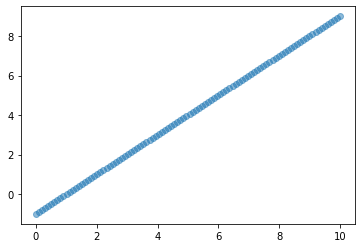

In [13]:
plt.scatter(x,y,alpha=0.5)
plt.show()

A perfect straight line is little too easy. So let's add some noise. That is, to each $y_i$ we add an independent random variable $\varepsilon_i$ with a standard Normal distribution (mean $0$, variance $1$).

In [14]:
y += rng.normal(0,1,n)

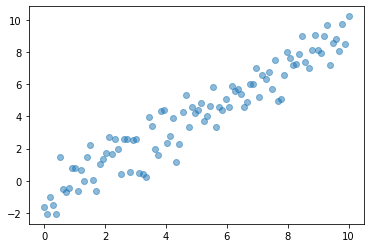

In [15]:
plt.scatter(x,y,alpha=0.5)
plt.show()

We form the matrix $A$ and use our least-squares code to solve for $\boldsymbol{\hat\beta}$. 

In [16]:
A = np.stack((np.ones(n),x),axis=-1)
coeff = ls_by_chol(A,y)
print(coeff)

[-1.03381171  1.01808039]


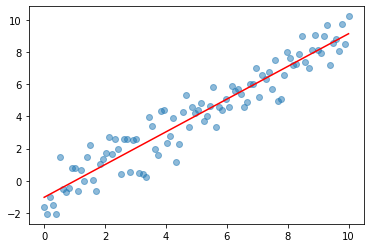

In [17]:
plt.scatter(x,y,alpha=0.5)
plt.plot(x,coeff[0]+coeff[1]*x,'r')
plt.show()

$\unlhd$

**Beyond linearity** The linear assumption is not as restrictive as it may first appear. The same approach can be extended straightforwardly to fit polynomials or more complicated combination of functions. For instance, suppose $d=1$. To fit a second degree polynomial to the data $\{(x_i, y_i)\}_{i=1}^n$, we add a column to the $A$ matrix with the squares of the $x_i$'s. That is, we let

$$
A =
\begin{pmatrix}
1 & x_1 & x_1^2 \\
1 & x_2 & x_2^2 \\
\vdots & \vdots & \vdots \\
1 & x_n & x_n^2
\end{pmatrix}.
$$

Then, we are indeed fitting a degree-two polynomial as follows 

$$
(A \boldsymbol{\beta})_i 
= \beta_0 + \beta_1 x_i + \beta_2 x_i^2.
$$

The solution otherwise remains the same. 

This idea of adding columns can also be used to model interactions between predictors. Suppose $d=2$. Then we can consider the following $A$ matrix, where the last column combines both predictors into their product,

$$
A =
\begin{pmatrix}
1 & x_{11} & x_{12} & x_{11} x_{12} \\
1 & x_{21} & x_{22} & x_{21} x_{22} \\
\vdots & \vdots & \vdots & \vdots\\
1 & x_{n1} & x_{n2} & x_{n1} x_{n2}
\end{pmatrix}.
$$

**NUMERICAL CORNER:** Suppose the truth is in fact a degree-two polynomial of one variable with Gaussian noise.

In [18]:
n, b0, b1, b2 = 100, 0, 0, 1
x = np.linspace(0,10,num=n)
y = b0 + b1 * x + b2 * x**2 + 10*rng.normal(0,1,n)

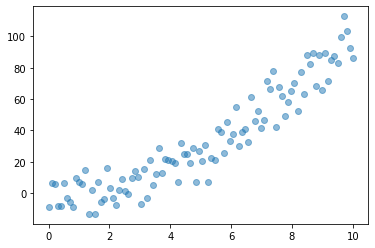

In [19]:
plt.scatter(x,y,alpha=0.5)
plt.show()

We form the matrix $A$ and use our least-squares code to solve for $\boldsymbol{\hat\beta}$. 

In [20]:
A = np.stack((np.ones(n), x, x**2), axis=-1)
coeff = ls_by_chol(A,y)
print(coeff)

[-2.76266982  1.01627798  0.93554204]


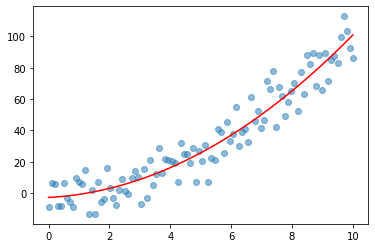

In [21]:
plt.scatter(x,y,alpha=0.5)
plt.plot(x, coeff[0] + coeff[1] * x + coeff[2] * x**2, 'r')
plt.show()

$\unlhd$